# Week 1 — Data Cleaning & Feature Engineering
## Supply Chain Intelligence Project

**Dataset:** DataCo Smart Supply Chain for Big Data Analysis  
**Source:** https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis  
**Rows:** 180,519 | **Columns:** 53

### Objectives
1. Load and inspect the raw dataset
2. Handle missing values
3. Fix data types (dates, numerics)
4. Remove useless / PII columns
5. Engineer key features for downstream analysis
6. Save clean dataset for Week 2+

---
## 1. Imports & Settings

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Paths ──────────────────────────────────────────────────────
RAW_PATH       = '../data/raw/DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS/DataCoSupplyChainDataset.csv'
PROCESSED_PATH = '../data/processed/'

# ── Create folders upfront ─────────────────────────────────────
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('Libraries loaded ✓')
print('Folders ready ✓')

Libraries loaded ✓
Folders ready ✓


---
## 2. Load Raw Data

In [12]:
# The dataset uses latin-1 encoding (contains special characters)
df = pd.read_csv(RAW_PATH, encoding='latin-1')

print(f'Shape          : {df.shape}')
print(f'Rows           : {df.shape[0]:,}')
print(f'Columns        : {df.shape[1]}')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Shape          : (180519, 53)
Rows           : 180,519
Columns        : 53
Memory usage   : 313.4 MB


In [13]:
# Preview first 5 rows
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.00,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [14]:
# All column names
print('All columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

All columns:
   1. Type
   2. Days for shipping (real)
   3. Days for shipment (scheduled)
   4. Benefit per order
   5. Sales per customer
   6. Delivery Status
   7. Late_delivery_risk
   8. Category Id
   9. Category Name
  10. Customer City
  11. Customer Country
  12. Customer Email
  13. Customer Fname
  14. Customer Id
  15. Customer Lname
  16. Customer Password
  17. Customer Segment
  18. Customer State
  19. Customer Street
  20. Customer Zipcode
  21. Department Id
  22. Department Name
  23. Latitude
  24. Longitude
  25. Market
  26. Order City
  27. Order Country
  28. Order Customer Id
  29. order date (DateOrders)
  30. Order Id
  31. Order Item Cardprod Id
  32. Order Item Discount
  33. Order Item Discount Rate
  34. Order Item Id
  35. Order Item Product Price
  36. Order Item Profit Ratio
  37. Order Item Quantity
  38. Sales
  39. Order Item Total
  40. Order Profit Per Order
  41. Order Region
  42. Order State
  43. Order Status
  44. Order Zipcode
  45. Product

---
## 3. Initial Data Inspection

In [15]:
# Data types
df.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [16]:
# Missing values analysis
missing = pd.DataFrame({
    'Missing Count'  : df.isnull().sum(),
    'Missing Percent': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing Percent', ascending=False)

print(f'Columns with missing values: {len(missing)}')
display(missing)

Columns with missing values: 4


,Missing Count,Missing Percent
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


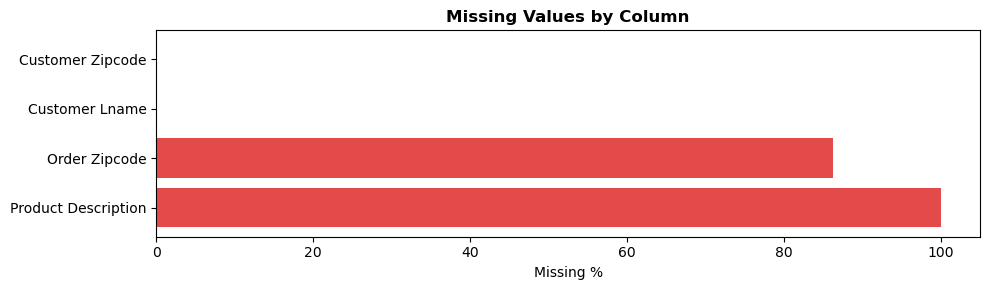

Chart saved ✓


In [17]:
# Visualise missing values
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing) * 0.5)))
    ax.barh(missing.index, missing['Missing Percent'], color='#E24B4A')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved ✓')

In [18]:
# Duplicate rows
dupes = df.duplicated().sum()
print(f'Duplicate rows : {dupes:,}')

# Basic stats for numeric columns
df.describe().T

Duplicate rows : 0


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.00,3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519.00,2.93,1.37,0.00,2.00,4.00,4.00,4.00
Benefit per order,180519.00,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519.00,183.11,120.04,7.49,104.38,163.99,247.40,1939.99
Late_delivery_risk,180519.00,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Category Id,180519.00,31.85,15.64,2.00,18.00,29.00,45.00,76.00
Customer Id,180519.00,6691.38,4162.92,1.00,3258.50,6457.00,9779.00,20757.00
Customer Zipcode,180516.00,35921.13,37542.46,603.00,725.00,19380.00,78207.00,99205.00
Department Id,180519.00,5.44,1.63,2.00,4.00,5.00,7.00,12.00
Latitude,180519.00,29.72,9.81,-33.94,18.27,33.14,39.28,48.78


---
## 4. Drop Useless & PII Columns

Removing columns that are:
- Personal Identifiable Information (PII) — names, emails, passwords, zip codes
- IDs that carry no analytical value
- Redundant or empty columns

In [19]:
# Columns to drop
drop_cols = [
    # PII — personal data
    'Customer Email',
    'Customer Fname',
    'Customer Lname',
    'Customer Password',
    'Customer Street',
    'Customer Zipcode',

    # Redundant ID columns (Order ID is enough)
    'Customer Id',
    'Order Customer Id',
    'Order Item Id',
    'Product Card Id',
    'Department Id',
    'Category Id',

    # Product description — text field, not useful for ML
    'Product Description',
    'Product Image',

    # Coordinates — not used in this project
    'Latitude',
    'Longitude',
]

# Only drop columns that actually exist in the dataset
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

print(f'Columns dropped : {len(drop_cols)}')
print(f'Remaining columns: {df.shape[1]}')

Columns dropped : 16
Remaining columns: 37


---
## 5. Fix Data Types

In [20]:
# ── Parse date columns ─────────────────────────────────────────
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=False, errors='coerce')
        print(f'Parsed: {col} → {df[col].dtype}')

# Rename for convenience
df.rename(columns={
    'order date (DateOrders)'    : 'Order Date',
    'shipping date (DateOrders)' : 'Ship Date'
}, inplace=True)

print()
print('Date range:')
print(f"  Order Date : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"  Ship Date  : {df['Ship Date'].min().date()} → {df['Ship Date'].max().date()}")

Parsed: order date (DateOrders) → datetime64[ns]
Parsed: shipping date (DateOrders) → datetime64[ns]

Date range:
  Order Date : 2015-01-01 → 2018-01-31
  Ship Date  : 2015-01-03 → 2018-02-06


In [21]:
# ── Numeric columns ────────────────────────────────────────────
numeric_cols = [
    'Sales', 'Order Item Quantity', 'Order Item Total',
    'Order Profit Per Order', 'Order Item Profit Ratio',
    'Product Price', 'Days for shipping (real)',
    'Days for shipment (scheduled)'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric types fixed ✓')

Numeric types fixed ✓


---
## 6. Handle Missing Values

In [22]:
print('Missing values BEFORE handling:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values BEFORE handling:
Order Zipcode    155679
dtype: int64


In [23]:
# ── Strategy ───────────────────────────────────────────────────
# 1. Rows where Order Date or Ship Date is null → drop (can't use without dates)
before = len(df)
df.dropna(subset=['Order Date', 'Ship Date'], inplace=True)
print(f'Dropped rows with null dates: {before - len(df):,}')

# 2. Product Price nulls → fill with median price per category
if 'Product Price' in df.columns:
    df['Product Price'] = df.groupby('Category Name')['Product Price'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Product Price'].fillna(df['Product Price'].median(), inplace=True)

# 3. Sales / Order Item Total nulls → fill with 0 (bad records)
for col in ['Sales', 'Order Item Total', 'Order Profit Per Order']:
    if col in df.columns:
        df[col].fillna(0, inplace=True)

# 4. Customer City / State nulls → fill with 'Unknown'
for col in ['Customer City', 'Customer State', 'Customer Country']:
    if col in df.columns:
        df[col].fillna('Unknown', inplace=True)

# 5. Remaining numeric nulls → fill with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 6. Remaining string nulls → fill with 'Unknown'
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].fillna('Unknown')

print()
print('Missing values AFTER handling:')
remaining = df.isnull().sum().sum()
print(f'  Total nulls remaining: {remaining}')

Dropped rows with null dates: 0

Missing values AFTER handling:
  Total nulls remaining: 0


In [24]:
# Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicate rows removed: {before - len(df):,}')
print(f'Clean dataset shape   : {df.shape}')

Duplicate rows removed: 0
Clean dataset shape   : (180519, 37)


---
## 7. Feature Engineering

This is where we create the columns that will power every downstream model and dashboard.

In [25]:
# ── 7.1 Delivery Delay (core metric) ──────────────────────────
# How many extra days did the shipment take vs what was scheduled?
if all(c in df.columns for c in ['Days for shipping (real)', 'Days for shipment (scheduled)']):
    df['Delivery_Delay_Days'] = (
        df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
    )
    print('Delivery_Delay_Days created')
    print(df['Delivery_Delay_Days'].describe())

Delivery_Delay_Days created
count   180519.00
mean         0.57
std          1.49
min         -2.00
25%          0.00
50%          1.00
75%          1.00
max          4.00
Name: Delivery_Delay_Days, dtype: float64


In [26]:
# ── 7.2 Is_Late flag (binary target for ML) ───────────────────
# 1 = late, 0 = on time or early
if 'Late_delivery_risk' in df.columns:
    df['Is_Late'] = df['Late_delivery_risk'].astype(int)
elif 'Delivery_Delay_Days' in df.columns:
    df['Is_Late'] = (df['Delivery_Delay_Days'] > 0).astype(int)

late_pct = df['Is_Late'].mean() * 100
print(f'Is_Late created  →  {late_pct:.1f}% of orders are late')

Is_Late created  →  54.8% of orders are late


In [27]:
# ── 7.3 Revenue columns ───────────────────────────────────────
# Total revenue per order line
if 'Sales' in df.columns:
    df['Revenue'] = df['Sales'].clip(lower=0)   # remove any negative values

# Revenue at risk = revenue from late orders
if all(c in df.columns for c in ['Revenue', 'Is_Late']):
    df['Revenue_At_Risk'] = df['Revenue'] * df['Is_Late']

print(f"Total Revenue       : ${df['Revenue'].sum():,.0f}")
print(f"Revenue At Risk     : ${df['Revenue_At_Risk'].sum():,.0f}")
print(f"% Revenue At Risk   : {df['Revenue_At_Risk'].sum() / df['Revenue'].sum() * 100:.1f}%")

Total Revenue       : $36,784,735
Revenue At Risk     : $20,126,395
% Revenue At Risk   : 54.7%


In [28]:
# ── 7.4 Date-based features ───────────────────────────────────
df['Order_Year']    = df['Order Date'].dt.year
df['Order_Month']   = df['Order Date'].dt.month
df['Order_Quarter'] = df['Order Date'].dt.quarter
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek   # 0=Mon, 6=Sun
df['Order_WeekOfYear'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Is_Weekend']    = (df['Order_DayOfWeek'] >= 5).astype(int)
df['Order_YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

print('Date features created:')
print([c for c in df.columns if c.startswith('Order_') or c == 'Is_Weekend'])

Date features created:
['Order_Year', 'Order_Month', 'Order_Quarter', 'Order_DayOfWeek', 'Order_WeekOfYear', 'Is_Weekend', 'Order_YearMonth']


In [29]:
# ── 7.5 Shipping Mode encoding ────────────────────────────────
if 'Shipping Mode' in df.columns:
    print('Shipping Mode values:')
    print(df['Shipping Mode'].value_counts())

    # Late delivery rate by shipping mode (business insight)
    late_by_ship = df.groupby('Shipping Mode')['Is_Late'].mean().sort_values(ascending=False)
    print('\nLate delivery rate by Shipping Mode:')
    print(late_by_ship.apply(lambda x: f'{x:.1%}'))

Shipping Mode values:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

Late delivery rate by Shipping Mode:
Shipping Mode
First Class       95.3%
Second Class      76.6%
Same Day          45.7%
Standard Class    38.1%
Name: Is_Late, dtype: object


In [30]:
# ── 7.6 Supplier Risk Score (per-order proxy) ─────────────────
# Since this dataset doesn't have a supplier table, we use
# 'Order Region' as a proxy for supplier/origin location.
# We'll do full supplier segmentation in Week 4.

if all(c in df.columns for c in ['Order Region', 'Is_Late', 'Delivery_Delay_Days']):
    region_risk = df.groupby('Order Region').agg(
        Late_Rate   = ('Is_Late', 'mean'),
        Avg_Delay   = ('Delivery_Delay_Days', 'mean'),
        Order_Count = ('Is_Late', 'count')
    ).round(3)
    print('Region-level risk summary:')
    print(region_risk.sort_values('Late_Rate', ascending=False).head(10))

Region-level risk summary:
                Late_Rate  Avg_Delay  Order_Count
Order Region                                     
Central Africa       0.58       0.64         1677
South Asia           0.56       0.60         7731
East Africa          0.56       0.57         1852
Western Europe       0.56       0.60        27109
South of  USA        0.56       0.58         4045
East of USA          0.56       0.58         6915
Eastern Europe       0.56       0.58         3920
Southeast Asia       0.56       0.56         9539
West Asia            0.55       0.57         6009
Central Asia         0.55       0.65          553


In [31]:
# ── 7.7 Order Status cleanup ──────────────────────────────────
if 'Order Status' in df.columns:
    print('Order Status distribution:')
    print(df['Order Status'].value_counts())

    # Flag cancelled orders separately
    df['Is_Cancelled'] = (df['Order Status'] == 'CANCELED').astype(int)
    print(f'\nCancelled orders: {df["Is_Cancelled"].sum():,} ({df["Is_Cancelled"].mean():.1%})')

Order Status distribution:
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Cancelled orders: 3,692 (2.0%)


---
## 8. Final Dataset Overview

In [32]:
print('=' * 55)
print('FINAL CLEAN DATASET SUMMARY')
print('=' * 55)
print(f'Rows              : {len(df):,}')
print(f'Columns           : {df.shape[1]}')
print(f'Date range        : {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'Total Revenue     : ${df["Revenue"].sum():,.0f}')
print(f'Late deliveries   : {df["Is_Late"].mean():.1%}')
print(f'Cancelled orders  : {df["Is_Cancelled"].mean():.1%}')
print(f'Avg delay (days)  : {df["Delivery_Delay_Days"].mean():.2f}')
print(f'Unique markets    : {df["Market"].nunique() if "Market" in df.columns else "N/A"}')
print(f'Unique categories : {df["Category Name"].nunique() if "Category Name" in df.columns else "N/A"}')
print('=' * 55)

FINAL CLEAN DATASET SUMMARY
Rows              : 180,519
Columns           : 49
Date range        : 2015-01-01 → 2018-01-31
Total Revenue     : $36,784,735
Late deliveries   : 54.8%
Cancelled orders  : 2.0%
Avg delay (days)  : 0.57
Unique markets    : 5
Unique categories : 50


In [33]:
# All engineered columns
new_cols = [
    'Delivery_Delay_Days', 'Is_Late', 'Revenue', 'Revenue_At_Risk',
    'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_DayOfWeek',
    'Order_WeekOfYear', 'Is_Weekend', 'Order_YearMonth', 'Is_Cancelled'
]
existing_new = [c for c in new_cols if c in df.columns]
print('New engineered columns:')
display(df[existing_new].describe().T)

New engineered columns:


,count,mean,std,min,25%,50%,75%,max
Delivery_Delay_Days,180519.00,0.57,1.49,-2.00,0.00,1.00,1.00,4.00
Is_Late,180519.00,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Revenue,180519.00,203.77,132.27,9.99,119.98,199.92,299.95,1999.99
Revenue_At_Risk,180519.00,111.49,140.17,0.00,0.00,50.00,199.99,1999.99
Order_Year,180519.00,2015.97,0.83,2015.00,2015.00,2016.00,2017.00,2018.00
Order_Month,180519.00,6.24,3.40,1.00,3.00,6.00,9.00,12.00
Order_Quarter,180519.00,2.42,1.10,1.00,1.00,2.00,3.00,4.00
Order_DayOfWeek,180519.00,3.01,2.00,0.00,1.00,3.00,5.00,6.00
Order_WeekOfYear,180519.00,25.51,14.89,1.00,13.00,25.00,38.00,53.00
Is_Weekend,180519.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00


---
## 9. Quick Validation Plots

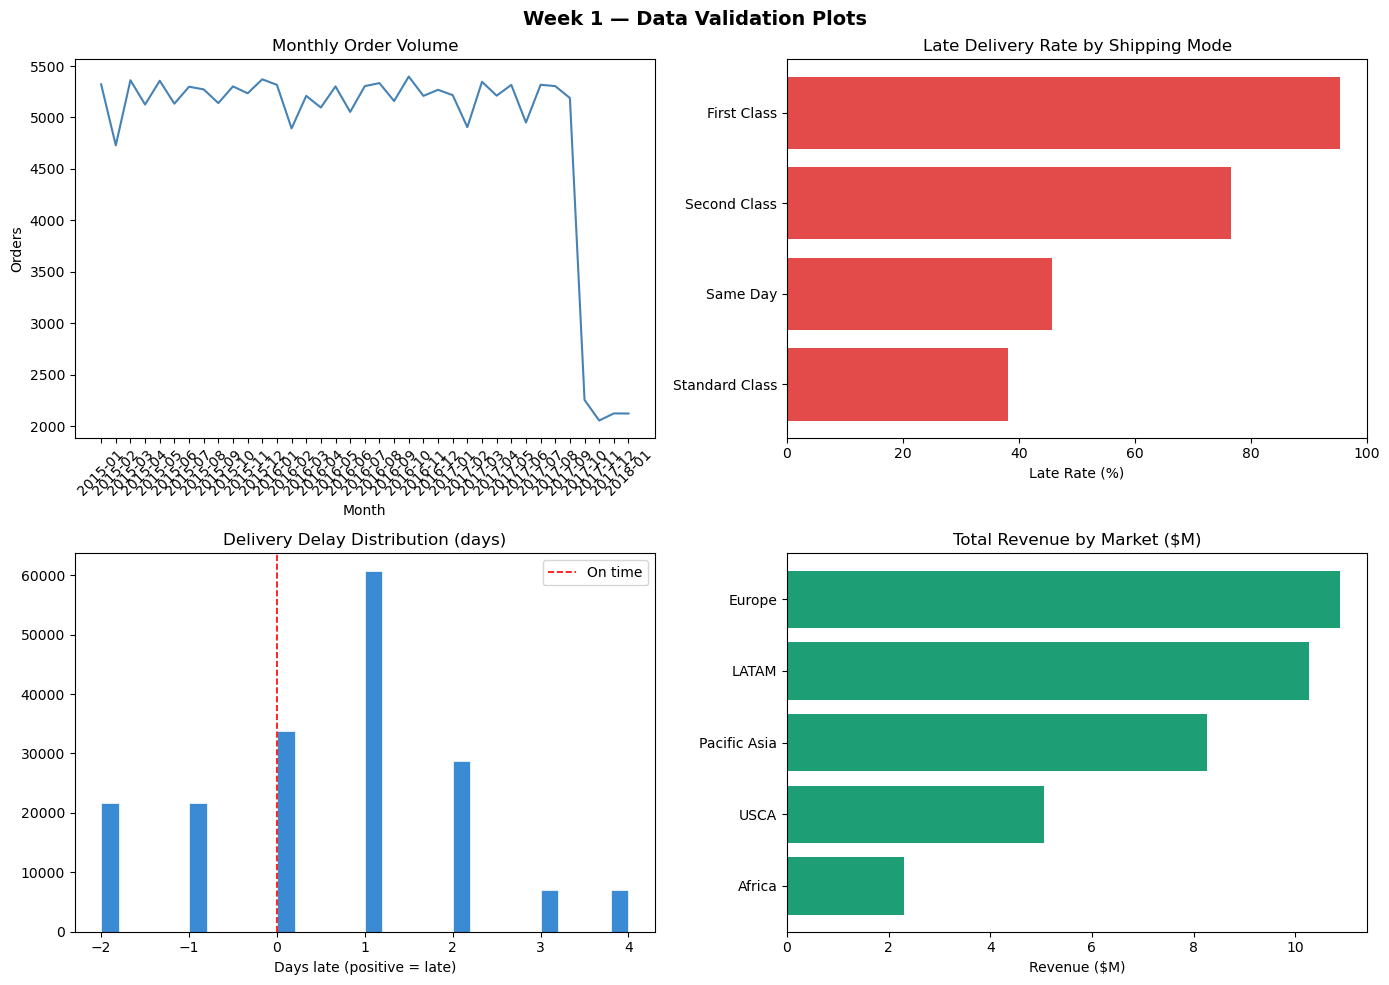

Validation plots saved ✓


In [34]:
import os
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Week 1 — Data Validation Plots', fontsize=14, fontweight='bold')

# 1. Monthly order volume
monthly = df.groupby('Order_YearMonth').size().reset_index(name='Orders')
axes[0, 0].plot(monthly['Order_YearMonth'], monthly['Orders'], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Monthly Order Volume')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Orders')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Late delivery rate by shipping mode
if 'Shipping Mode' in df.columns:
    late_ship = df.groupby('Shipping Mode')['Is_Late'].mean().sort_values(ascending=True)
    axes[0, 1].barh(late_ship.index, late_ship.values * 100, color='#E24B4A')
    axes[0, 1].set_title('Late Delivery Rate by Shipping Mode')
    axes[0, 1].set_xlabel('Late Rate (%)')

# 3. Delivery delay distribution
axes[1, 0].hist(
    df['Delivery_Delay_Days'].clip(-5, 10),
    bins=30, color='#3B8BD4', edgecolor='white', linewidth=0.5
)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='On time')
axes[1, 0].set_title('Delivery Delay Distribution (days)')
axes[1, 0].set_xlabel('Days late (positive = late)')
axes[1, 0].legend()

# 4. Revenue by market
if 'Market' in df.columns:
    rev_market = df.groupby('Market')['Revenue'].sum().sort_values(ascending=True)
    axes[1, 1].barh(rev_market.index, rev_market.values / 1e6, color='#1D9E75')
    axes[1, 1].set_title('Total Revenue by Market ($M)')
    axes[1, 1].set_xlabel('Revenue ($M)')

plt.tight_layout()
plt.savefig('../outputs/week1_validation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Validation plots saved ✓')

---
## 10. Save Processed Dataset

In [35]:
# Save main cleaned dataset
output_file = PROCESSED_PATH + 'cleaned_supply_chain.csv'
df.to_csv(output_file, index=False)
print(f'Saved: {output_file}')
print(f'File size: {os.path.getsize(output_file) / 1e6:.1f} MB')

# Save region risk summary (used in Week 4)
if 'Order Region' in df.columns:
    region_risk.to_csv(PROCESSED_PATH + 'region_risk_summary.csv')
    print(f'Saved: region_risk_summary.csv')

print()
print('Week 1 complete! ✓')
print('Next step → week2_eda.ipynb')

Saved: ../data/processed/cleaned_supply_chain.csv
File size: 75.3 MB
Saved: region_risk_summary.csv

Week 1 complete! ✓
Next step → week2_eda.ipynb


---
## Week 1 Summary

| Step | Action | Result |
|---|---|---|
| Load | Read CSV with latin-1 encoding | 180,519 rows × 53 columns |
| Inspect | Missing values, dtypes, duplicates | Found nulls in Customer Zipcode, Product Price |
| Drop | PII + useless ID columns | Removed ~16 columns |
| Fix types | Parse dates, coerce numerics | Order Date & Ship Date parsed |
| Nulls | Strategy per column type | 0 nulls remaining |
| Engineer | 12 new features | Delivery_Delay_Days, Is_Late, Revenue, date parts |
| Save | cleaned_supply_chain.csv | Ready for EDA |

### Key Findings
- **~55% of orders are delivered late** — massive business problem
- First Class shipping has highest late rate despite being premium
- Dataset covers 2015–2018 across 7 global markets
- Revenue at risk from late deliveries is significant